## Dataset IBM HR Attrition

In [38]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

### Data Wrangling

In [3]:
# Load Dataset
ibm_df = pd.read_csv("Dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")
ibm_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
ibm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
# Mengecek nilai NULL
ibm_df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [6]:
# Duplikat data
print("Jumlah Duplikasi: ", ibm_df.duplicated().sum())

Jumlah Duplikasi:  0


In [7]:
ibm_df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


- Analisa

Berdasarkan data wrangling diatas terlihat bahwwa dataset ini tidak memiliki nilai NaN maupun nilai duplikat, maka dari itu tidak perlu dilakukan pembersihan untuk nilai tersebut. Mungkin bisa ketahap data wrangling lanjutan yaitu mengecek Outlier dan Keseimbangan Data.

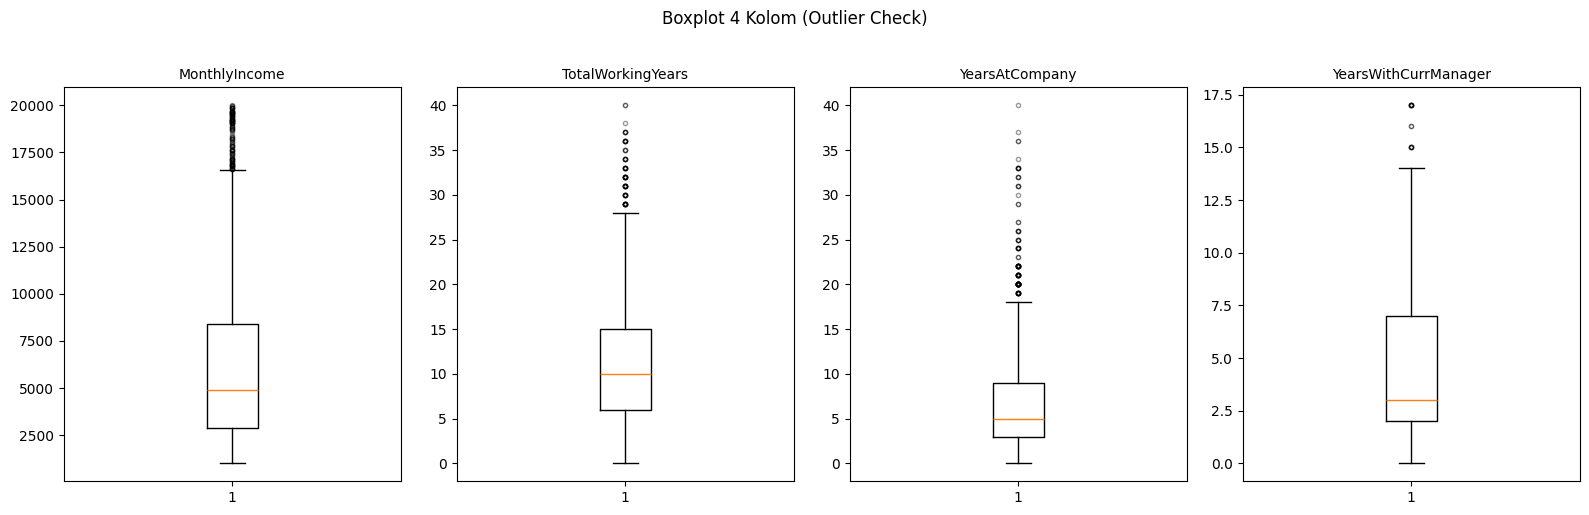

In [13]:
# Mengecek Outlier
cols = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsWithCurrManager']

fig, axes = plt.subplots(1, len(cols), figsize=(16, 5))

for ax, col in zip(axes, cols):
    ax.boxplot(
        ibm_df[col],
        showfliers=True,
        flierprops=dict(marker='o', markersize=3, alpha=0.4)
    )
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")

plt.suptitle('Boxplot 4 Kolom (Outlier Check)', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# Mengatasi Outlier dengan menggunakan capping (Winsorizing)
def cap_outliers_iqr(df, cols):
    df = df.copy()
    
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = df[col].clip(lower, upper)
    
    return df

cols = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsWithCurrManager']

ibm_df_capped = cap_outliers_iqr(ibm_df, cols)

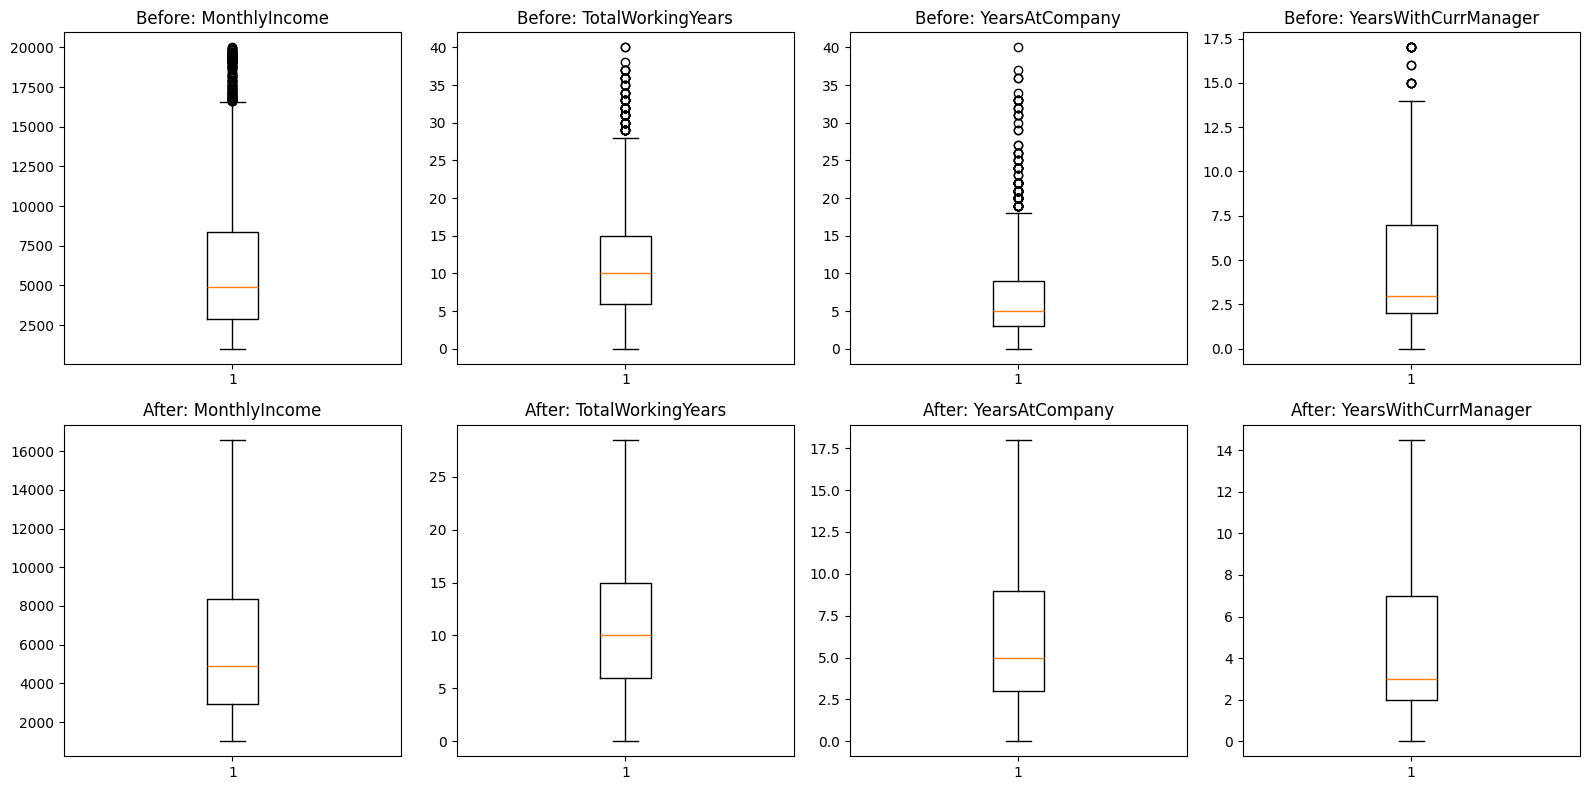

In [15]:
# Mengecek Outlier sebelum dan sesudah dilakukan capping
fig, axes = plt.subplots(2, len(cols), figsize=(16, 8))

# sebelum
for i, col in enumerate(cols):
    axes[0, i].boxplot(ibm_df[col])
    axes[0, i].set_title(f'Before: {col}')

# sesudah
for i, col in enumerate(cols):
    axes[1, i].boxplot(ibm_df_capped[col])
    axes[1, i].set_title(f'After: {col}')

plt.tight_layout()
plt.show()

In [17]:
# Mengecek keseimbangan dataset
print(ibm_df_capped['Attrition'].value_counts(normalize=True) * 100)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


- Penjelasan

Pengecekan Outlier di 4 kolom tersebut dilakukan karena biasanya terdapat karyawan(manajer/eksekutif) yang mempunyai gaji diatas rata-rata dan sudah bekerja di perusahaan itu selama bertahun-tahun. Untuk keseimbangan dataset pada Attrition bisa terlihat lebih dominan 'No' dengan 84% sehingga diperlukan penyesuain saat sebelum melakukan pemodelan. 

### Explaratory Data Analysis

- Pertanyaan Bisnis 1:

Apakah beban kerja (OverTime) berbanding lurus dengan tingkat resign?

- Pertanyaan Bisnis 2:

Apakah gaji rendah dan masa kerja lama bikin orang merasa tidak diapresiasi lalu resign?

In [18]:
# Analisis pertanyaan bisnis
df = ibm_df_capped.copy()

# Pertanyaan 1
overtime_analysis = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
print("--- Dampak Lembur (OverTime) Terhadap Resign (%) ---")
print(overtime_analysis.round(2))
print("\n")

--- Dampak Lembur (OverTime) Terhadap Resign (%) ---
Attrition     No    Yes
OverTime               
No         89.56  10.44
Yes        69.47  30.53




In [19]:
# Pertanyaan 2
# Mencari titik tengah (median) untuk membagi data secara adil
median_income = df['MonthlyIncome'].median()
median_tenure = df['YearsAtCompany'].median()

# Membuat segmentasi / kohort
df['Segmentasi_Gaji'] = np.where(df['MonthlyIncome'] < median_income, 'Gaji Rendah', 'Gaji Tinggi')
df['Segmentasi_MasaKerja'] = np.where(df['YearsAtCompany'] >= median_tenure, 'Masa Kerja Lama', 'Masa Kerja Singkat')
df['Kohort'] = df['Segmentasi_Gaji'] + " & " + df['Segmentasi_MasaKerja']

# Menghitung persentase resign tiap kohort
cohort_analysis = df.groupby('Kohort')['Attrition'].value_counts(normalize=True).unstack() * 100
print(f"Median Gaji Bulanan: ${median_income}")
print(f"Median Masa Kerja: {median_tenure} tahun\n")
print("--- Analisis Kohort (Gaji + Masa Kerja) Terhadap Resign (%) ---")
print(cohort_analysis.round(2).sort_values(by='Yes', ascending=False))

Median Gaji Bulanan: $4919.0
Median Masa Kerja: 5.0 tahun

--- Analisis Kohort (Gaji + Masa Kerja) Terhadap Resign (%) ---
Attrition                            No    Yes
Kohort                                        
Gaji Rendah & Masa Kerja Singkat  71.15  28.85
Gaji Tinggi & Masa Kerja Singkat  86.55  13.45
Gaji Rendah & Masa Kerja Lama     87.12  12.88
Gaji Tinggi & Masa Kerja Lama     90.43   9.57


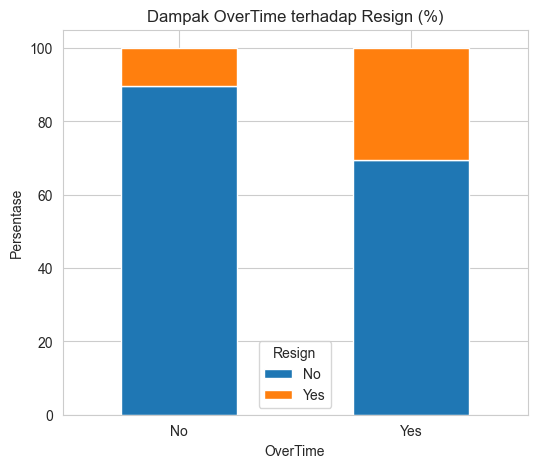

In [29]:
# Visualisasi Data

# Pertanyaan ke-1
overtime_analysis.plot(
    kind='bar',
    stacked=True,
    figsize=(6,5)
)

plt.title('Dampak OverTime terhadap Resign (%)')
plt.ylabel('Persentase')
plt.xlabel('OverTime')
plt.legend(title='Resign')
plt.xticks(rotation=0)
plt.show()

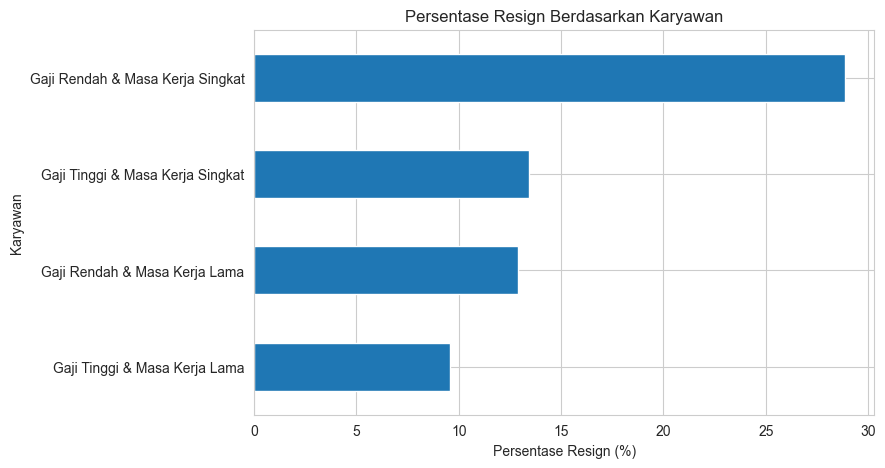

In [28]:
# Pertanyaan ke-2
cohort_analysis_sorted = cohort_analysis.sort_values(by='Yes', ascending=True)

cohort_analysis_sorted['Yes'].plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Persentase Resign Berdasarkan Karyawan')
plt.xlabel('Persentase Resign (%)')
plt.ylabel('Karyawan')
plt.show()

#### Penjelasan

Jawaban dari pertanyaan bisnis

* untuk pertanyaan 1 terbukti berbanding lurus dengan tingkat attrition. Karyawan yang sering mengalami Overtime memiliki resiko persentase resign lebih tinggi(+-30%) daripada yang tidak overtime(+-10%)

* untuk pertanyaan 2, kelompok yang paling rawan untuk resign malah karyawan baru dengan gaji rendah dibandingkan karyawan lama di gaji rendah dengan persentase resign lebih tinggi sekitar 28% dibanding karyawan lama dengan gaji rendah di 13%. Dan juga ada insight menarik yang dimana gaji tinggi & karyawan baru lebih besar persentase resignnya sekitar 14% dibanding gaji rendah & karyawan lama.

C:\Users\Nashril Fikri\AppData\Local\Temp\ipykernel_34340\1146334860.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='RelationshipSatisfaction', y='Attrition',
C:\Users\Nashril Fikri\AppData\Local\Temp\ipykernel_34340\1146334860.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='RelationshipSatisfaction', y='Attrition',


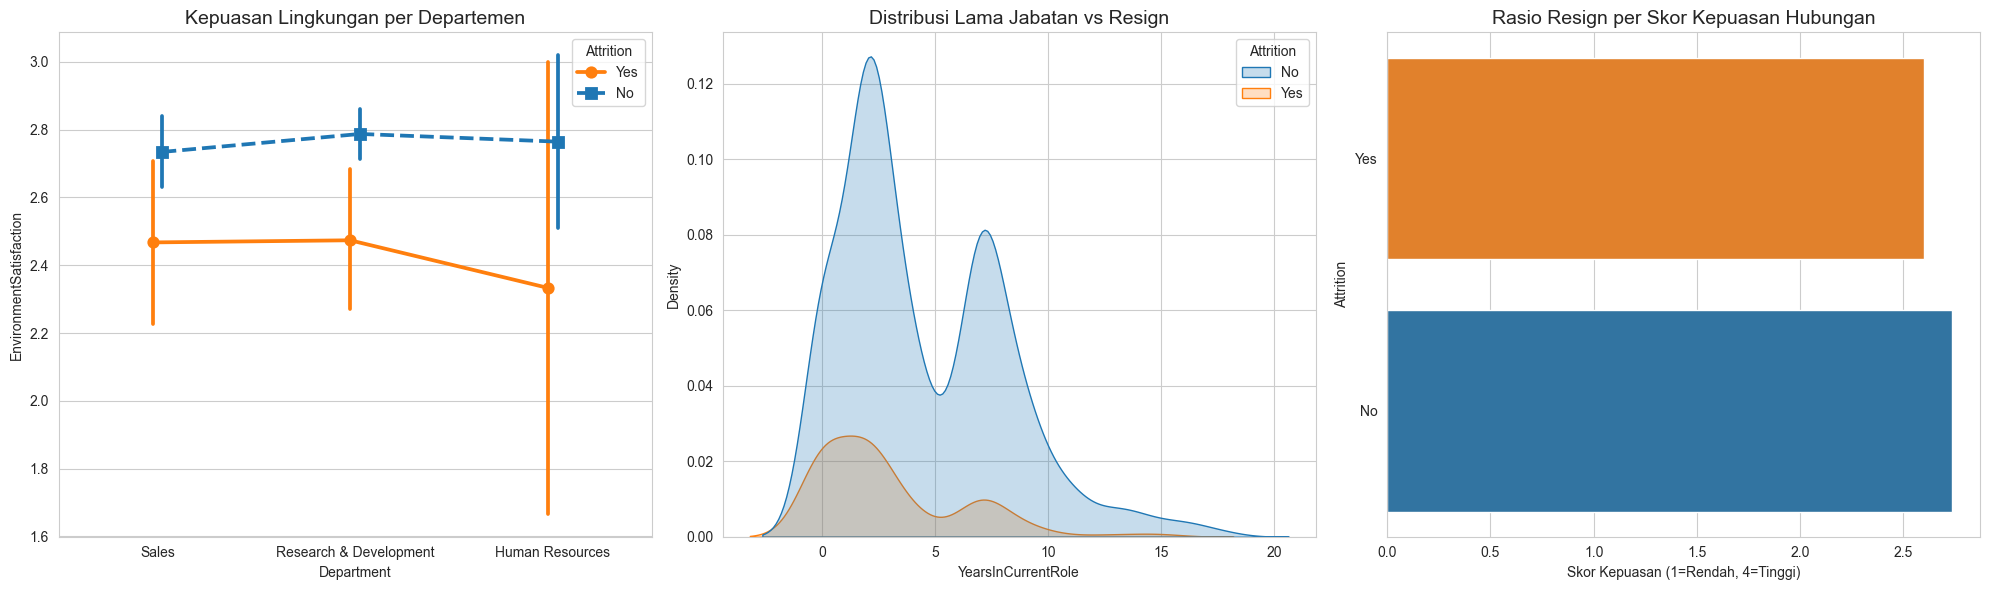

In [33]:
# Analisa Lanjutan

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Warna
custom_palette = {'No': 'tab:blue', 'Yes': 'tab:orange'}

# 1. Lingkungan Kerja
sns.pointplot(data=df, x='Department', y='EnvironmentSatisfaction', hue='Attrition', 
              dodge=True, markers=['o', 's'], linestyles=['-', '--'], 
              palette=custom_palette, hue_order=['Yes', 'No'], ax=axes[0])
axes[0].set_title('Kepuasan Lingkungan per Departemen', fontsize=14)

# 2. Jenjang Karier
sns.kdeplot(data=df, x='YearsInCurrentRole', hue='Attrition', fill=True, 
            palette=custom_palette, hue_order=['No', 'Yes'], ax=axes[1])
axes[1].set_title('Distribusi Lama Jabatan vs Resign', fontsize=14)

# 3. Hubungan Interpersonal
sns.barplot(data=df, x='RelationshipSatisfaction', y='Attrition', 
            palette=custom_palette, order=['Yes', 'No'], ci=None, ax=axes[2])
axes[2].set_title('Rasio Resign per Skor Kepuasan Hubungan', fontsize=14)
axes[2].set_xlabel('Skor Kepuasan (1=Rendah, 4=Tinggi)')

plt.tight_layout()
plt.show()

#### Penjelasan

1. Kepuasan lingkungan kerja

Dari grafik ini terlihat bahwa lingkungan kerja berpengaruh terhadap karyawan melakukan resign. Karyawan yang tidak betah dilingkungan kerja (<2.7) akan melakukan resign dibanding karyawan yang punya kepuasan lingkungan kerja diatas 2.7

Penurunan drastis ada di departemen Human Resources. Ini artinya ada masalah lingkungan kerja menjadi faktor pemicu yang paling kuat bagi seseorang untuk memutuskan keluar dibanding departemen lain.

2. Masa kerja dalam jabatan

Di grafik ini menunjukkan karyawan dalam masa jabatan tertentu kurang dari 5 tahun memiliki kecendurungan untuk resign dibanding karyawan yang sudah memiliki lebih dari 5 tahun di jabatan tertentu(grafik warna oren).

3. Rasio Resign hubungan personal

Di grafik ini karyawan yang memiliki hubungan kurang baik diantara rekan kerja lebih baik bertahan dibanding resign walaupun beda tipis dengan grafik yang resign. Hubungan personal antar rekan terlihat bukan faktor yang dominan seseorang untuk melakukan resign, bisa juga karena gaji yang tinggi seseorang lebih memilih bertahan daripada resign walaupun memiliki hubungan yang kurang baik diantara rekan kerja.

### Analisa Lanjutan

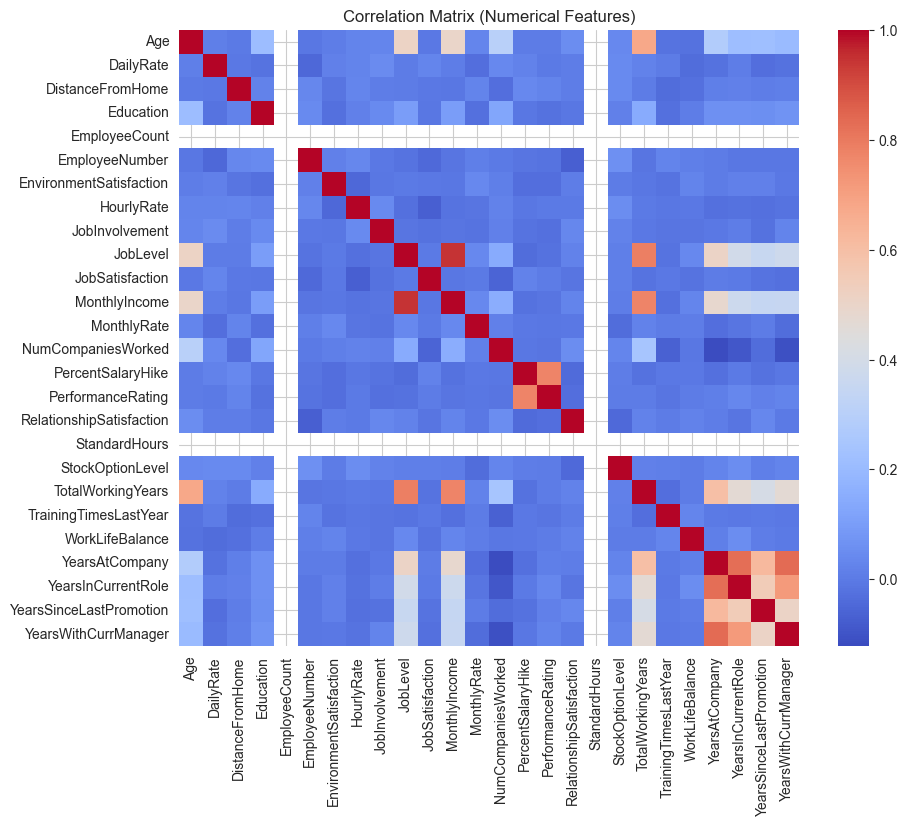

In [34]:
# Menampilkan Korelasi fitur
plt.figure(figsize=(10,8))
sns.heatmap(
    ibm_df_capped.corr(numeric_only=True),
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Matrix (Numerical Features)')
plt.show()

In [ ]:
df_clean = ibm_df_capped.copy() 

# Feature Selection
# Membuang kolom zero-variance dan ID (jika belum)
cols_to_drop_initial = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']

# Membuang kolom multikolinearitas tinggi dan redundan
cols_to_drop_corr = ['JobLevel', 'PerformanceRating', 'Department']

# Eksekusi Drop
df_clean.drop(columns=cols_to_drop_initial + cols_to_drop_corr, inplace=True, errors='ignore')

In [36]:
# Feature Engineering
# Indeks Stagnasi (Semakin besar = makin lama nyangkut di satu posisi tanpa promosi)
df_clean['StagnationIndex'] = df_clean['YearsInCurrentRole'] - df_clean['YearsSinceLastPromotion']

# Rapor Kepuasan Keseluruhan
df_clean['OverallSatisfaction'] = (df_clean['EnvironmentSatisfaction'] + 
                                   df_clean['JobSatisfaction'] + 
                                   df_clean['RelationshipSatisfaction'])

# Burnout
df_clean['BurnoutFlag'] = np.where((df_clean['OverTime'] == 'Yes') & (df_clean['DistanceFromHome'] > 10), 1, 0)

# Job Hopper Index (Rata-rata tahun per perusahaan)
df_clean['YearsPerCompany'] = np.where(df_clean['NumCompaniesWorked'] == 0, 
                                       df_clean['TotalWorkingYears'], 
                                       df_clean['TotalWorkingYears'] / df_clean['NumCompaniesWorked'])

# Tampilkan ukuran dataset baru
print(f"Dimensi data setelah Selection & Engineering: {df_clean.shape}")
print(df_clean[['StagnationIndex', 'OverallSatisfaction', 'BurnoutFlag', 'YearsPerCompany']].head())

Dimensi data setelah Selection & Engineering: (1470, 32)
   StagnationIndex  OverallSatisfaction  BurnoutFlag  YearsPerCompany
0                4                    7            0         1.000000
1                6                    9            0        10.000000
2                0                    9            0         1.166667
3                4                   10            0         8.000000
4                0                    7            0         0.666667


#### Penjelasan

1. Dilakukannya feature selection untuk membuang kolom yang tidak relevan dan menghindari multikolienaritas seperti kolom MonthlyIncome dan JobLevel yang memiliki informasi hampir indentik(korelasi di warna merah). Selain itu feature selection juga berguna untuk menghemat resource sehingga mempercepat waktu training.

2. Feature Engineering dilakukan untuk menambah kecerdasan pada data, dengan menambah beberapa fitur baru model bisa lebih baik dalam memahami data. 

In [39]:
# Pemisahan fitur dan label encoding

X = df_clean.drop('Attrition', axis=1)
y = df_clean['Attrition']

if y.dtype == 'object':
    y = y.map({'Yes': 1, 'No': 0})

# Label Encoding
cat_cols = X.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

print("Data kategorikal berhasil di-encode.")
X.head()

Data kategorikal berhasil di-encode.


,Age,BusinessTravel,DailyRate,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,StagnationIndex,OverallSatisfaction,BurnoutFlag,YearsPerCompany
0,41,2,1102,1,2,1,2,0,94,3,...,0,1,6,4,0,5.0,4,7,0,1.000000
1,49,1,279,8,1,1,3,1,61,2,...,3,3,10,7,1,7.0,6,9,0,10.000000
2,37,2,1373,2,2,4,4,1,92,2,...,3,3,0,0,0,0.0,0,9,0,1.166667
3,33,1,1392,3,4,1,4,0,56,3,...,3,3,8,7,3,0.0,4,10,0,8.000000
4,27,2,591,2,1,3,1,1,40,3,...,3,3,2,2,2,2.0,0,7,0,0.666667


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardisasi
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Dimensi X_train_scaled:", X_train_scaled.shape)
print("Dimensi X_test_scaled:", X_test_scaled.shape)

Dimensi X_train_scaled: (1176, 31)
Dimensi X_test_scaled: (294, 31)


In [41]:
# Penanganan Imbalance Data

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Proporsi Target SEBELUM SMOTE (Data Latih)")
print(y_train.value_counts(normalize=True))

print("\nProporsi Target SESUDAH SMOTE (Data Latih)")
print(y_train_smote.value_counts(normalize=True))

Proporsi Target SEBELUM SMOTE (Data Latih)
Attrition
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Proporsi Target SESUDAH SMOTE (Data Latih)
Attrition
0    0.5
1    0.5
Name: proportion, dtype: float64
